In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iamaniketdubey/credit-data/credit_risk.csv


In [38]:
df = pd.read_csv("/kaggle/input/datasets/iamaniketdubey/credit-data/credit_risk.csv")

In [39]:
df.head()

,income,debt_ratio,credit_score,loan_amount,loan_term_months,age,employment_years,num_credit_lines,num_late_payments,credit_utilization,...,mortgage_balance,annual_spend,num_bank_accounts,avg_transaction_value,num_inquiries_6mo,collateral_value,investment_balance,credit_history_years,risk_category,employment_type
0,-0.464580,1.526614,638.0,-6.339496,0.350506,24,-2.133639,0.048107,0.883843,-2.911817,...,0.485348,0.792439,-0.824339,2.646163,-2.566462,-0.032442,-0.085419,4.548498,High_Risk,Salaried
1,4.017065,1.185752,572.0,0.732662,-1.014284,22,1.594057,-2.531008,1.615773,5.659674,...,-0.559708,-0.842674,-0.370175,-1.195547,0.250621,4.019122,-2.516402,-3.595833,Low_Risk,Salaried
2,-0.635387,-2.662496,504.0,-0.516390,-3.494384,23,0.692334,0.530660,0.593272,-0.408990,...,-1.920335,-0.911276,-2.303786,3.814886,-2.071418,5.442083,-0.619695,-4.713383,Low_Risk,Salaried
3,0.217283,-0.877422,468.0,-1.099379,2.117065,23,-1.849336,-0.641152,2.013695,-2.527998,...,-0.231922,-0.087163,1.668250,-2.377077,-0.536020,-0.379421,-1.021003,-4.612215,Low_Risk,Salaried
4,2.739784,0.794094,460.0,4.736155,-1.545213,25,0.335158,-1.009353,2.940792,-2.712068,...,-0.446521,0.182940,-2.299213,1.067097,1.069284,7.882461,0.446097,-9.910932,Low_Risk,Salaried


In [40]:
df.shape

(10000, 24)

In [41]:
df.dtypes

income                   float64
debt_ratio               float64
credit_score             float64
loan_amount              float64
loan_term_months         float64
age                        int64
employment_years         float64
num_credit_lines         float64
num_late_payments        float64
credit_utilization       float64
savings_balance          float64
num_dependents           float64
monthly_expenses         float64
existing_loans           float64
mortgage_balance         float64
annual_spend             float64
num_bank_accounts        float64
avg_transaction_value    float64
num_inquiries_6mo        float64
collateral_value         float64
investment_balance       float64
credit_history_years     float64
risk_category             object
employment_type           object
dtype: object

In [42]:
df.isnull().sum()

income                   398
debt_ratio                 0
credit_score               0
loan_amount                0
loan_term_months           0
age                        0
employment_years         377
num_credit_lines           0
num_late_payments          0
credit_utilization         0
savings_balance          396
num_dependents             0
monthly_expenses           0
existing_loans             0
mortgage_balance           0
annual_spend               0
num_bank_accounts          0
avg_transaction_value      0
num_inquiries_6mo          0
collateral_value           0
investment_balance         0
credit_history_years       0
risk_category              0
employment_type            0
dtype: int64

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your target column is named 'target'
class_counts = df['risk_category'].value_counts()
class_percentages = df['risk_category'].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages)

Class Counts:
risk_category
Low_Risk       4953
Medium_Risk    2995
High_Risk      2052
Name: count, dtype: int64

Class Percentages:
risk_category
Low_Risk       49.53
Medium_Risk    29.95
High_Risk      20.52
Name: proportion, dtype: float64


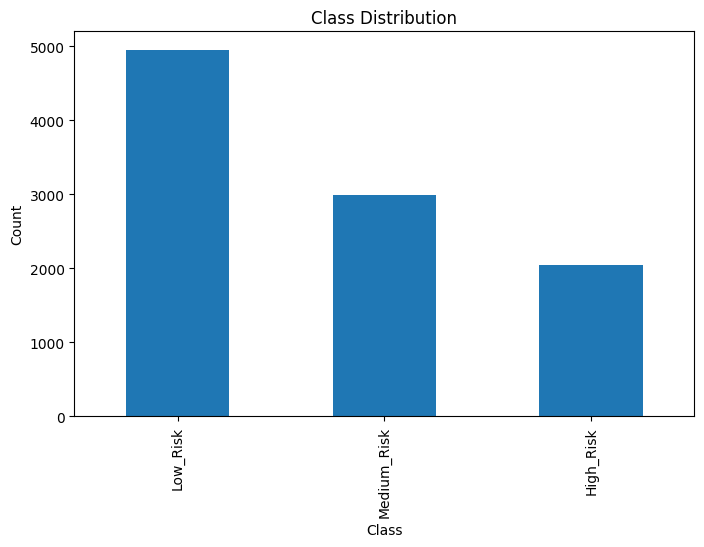

In [44]:
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

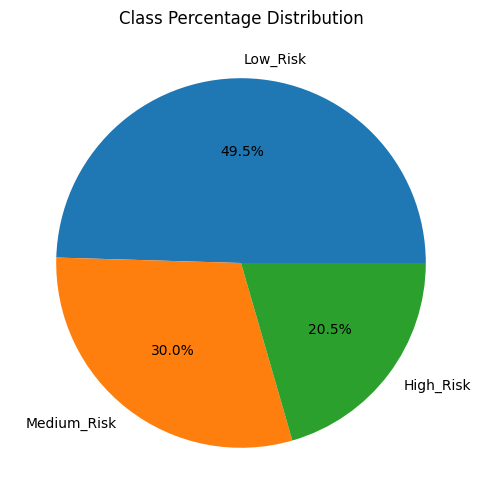

In [45]:
plt.figure(figsize=(6, 6))
class_percentages.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Class Percentage Distribution')
plt.ylabel('')
plt.show()

In [46]:
print(df.shape)
print(df.info())
print(df.describe(include='all').T)


(10000, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   income                 9602 non-null   float64
 1   debt_ratio             10000 non-null  float64
 2   credit_score           10000 non-null  float64
 3   loan_amount            10000 non-null  float64
 4   loan_term_months       10000 non-null  float64
 5   age                    10000 non-null  int64  
 6   employment_years       9623 non-null   float64
 7   num_credit_lines       10000 non-null  float64
 8   num_late_payments      10000 non-null  float64
 9   credit_utilization     10000 non-null  float64
 10  savings_balance        9604 non-null   float64
 11  num_dependents         10000 non-null  float64
 12  monthly_expenses       10000 non-null  float64
 13  existing_loans         10000 non-null  float64
 14  mortgage_balance       10000 non-null  floa

In [47]:
import seaborn as sns


                  missing_count  missing_pct
income                      398         3.98
savings_balance             396         3.96
employment_years            377         3.77


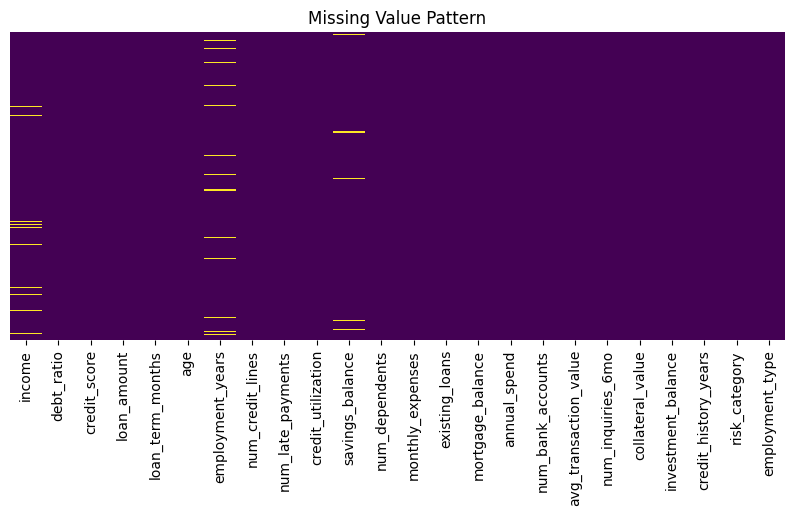

income              398
savings_balance     396
employment_years    377
dtype: int64

Rows missing in 2+ of these columns: 35


In [48]:
# Missingness summary
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False))

# Visualize missingness pattern
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Value Pattern")
plt.show()

# Check: do missing values cluster in same rows, or are they independent?
missing_cols = ['income', 'savings_balance', 'employment_years']
print(df[missing_cols].isnull().sum())
print("\nRows missing in 2+ of these columns:", (df[missing_cols].isnull().sum(axis=1) >= 2).sum())

In [49]:
df_new = (df.isnull().sum()/len(df))*100

In [50]:
df_new

income                   3.98
debt_ratio               0.00
credit_score             0.00
loan_amount              0.00
loan_term_months         0.00
age                      0.00
employment_years         3.77
num_credit_lines         0.00
num_late_payments        0.00
credit_utilization       0.00
savings_balance          3.96
num_dependents           0.00
monthly_expenses         0.00
existing_loans           0.00
mortgage_balance         0.00
annual_spend             0.00
num_bank_accounts        0.00
avg_transaction_value    0.00
num_inquiries_6mo        0.00
collateral_value         0.00
investment_balance       0.00
credit_history_years     0.00
risk_category            0.00
employment_type          0.00
dtype: float64

In [51]:
df_new = df_new[(df.isnull().sum()/len(df))*100>0]

In [52]:
df_new

income              3.98
employment_years    3.77
savings_balance     3.96
dtype: float64

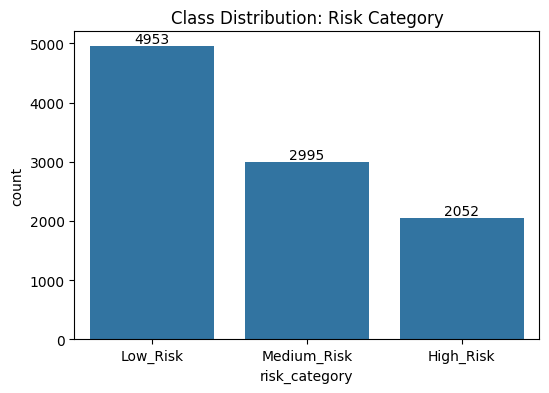

risk_category
Low_Risk       49.53
Medium_Risk    29.95
High_Risk      20.52
Name: proportion, dtype: float64


In [53]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='risk_category', order=['Low_Risk', 'Medium_Risk', 'High_Risk'])
plt.title("Class Distribution: Risk Category")
for i, v in enumerate(df['risk_category'].value_counts()[['Low_Risk', 'Medium_Risk', 'High_Risk']]):
    plt.text(i, v + 50, str(v), ha='center')
plt.show()

print(df['risk_category'].value_counts(normalize=True) * 100)

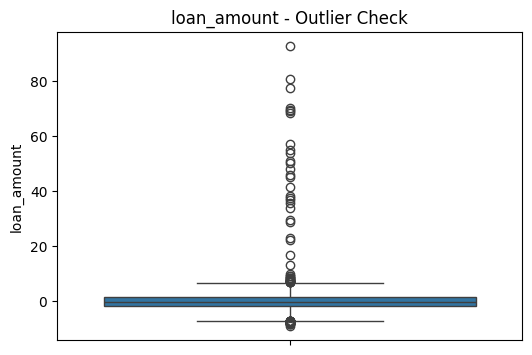

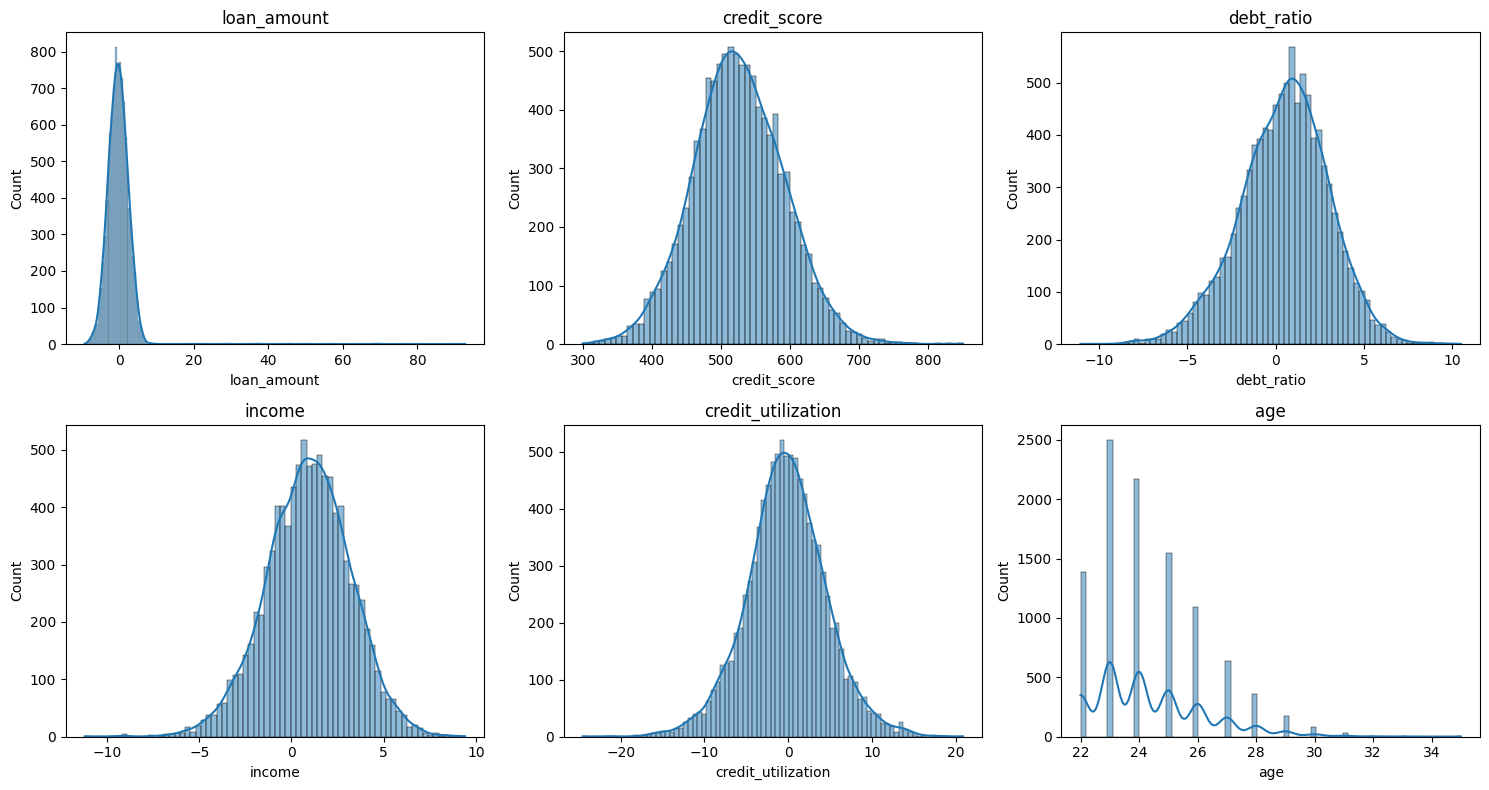

In [54]:
# Boxplot to visually confirm outliers in loan_amount
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, y='loan_amount')
plt.title("loan_amount - Outlier Check")
plt.show()

# Histogram grid for a sample of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
sample_cols = ['loan_amount', 'credit_score', 'debt_ratio', 'income',
               'credit_utilization', 'age']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), sample_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

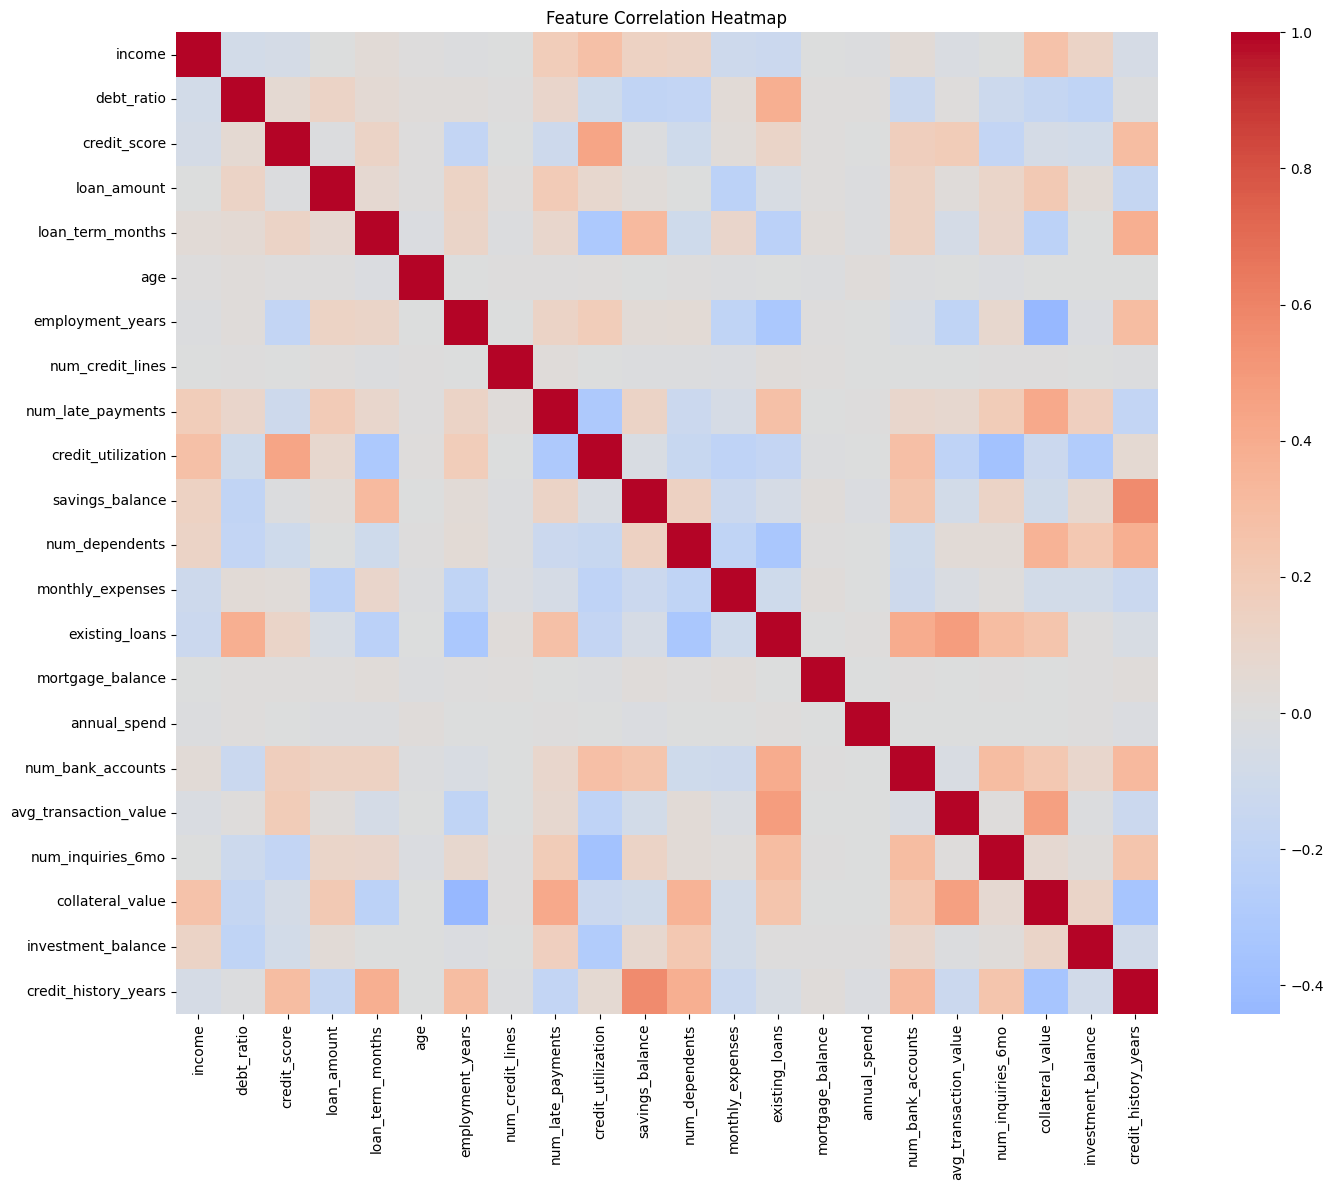

savings_balance       credit_history_years     0.565635
existing_loans        avg_transaction_value    0.481234
collateral_value      avg_transaction_value    0.462039
employment_years      collateral_value         0.441771
credit_score          credit_utilization       0.437275
num_late_payments     collateral_value         0.416526
num_bank_accounts     existing_loans           0.399452
loan_term_months      credit_history_years     0.384948
credit_history_years  num_dependents           0.382306
debt_ratio            existing_loans           0.381145
num_dependents        collateral_value         0.367218
credit_utilization    num_inquiries_6mo        0.364890
collateral_value      credit_history_years     0.344483
existing_loans        num_dependents           0.330912
employment_years      existing_loans           0.322190
dtype: float64


In [55]:
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Pull out the strongest pairwise correlations (excluding self-correlation)
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # remove self-correlations
top_corr = corr_pairs.sort_values(ascending=False).drop_duplicates().head(15)
print(top_corr)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


vif_data = numeric_df.dropna()
vif_data = add_constant(vif_data)

vif_df = pd.DataFrame()
vif_df["feature"] = vif_data.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
vif_df = vif_df[vif_df["feature"] != "const"].sort_values("VIF", ascending=False)
print(vif_df)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                  feature           VIF
1                  income           inf
2              debt_ratio           inf
5        loan_term_months           inf
10     credit_utilization           inf
9       num_late_payments           inf
7        employment_years           inf
21     investment_balance           inf
17      num_bank_accounts           inf
20       collateral_value           inf
11        savings_balance           inf
13       monthly_expenses           inf
12         num_dependents           inf
14         existing_loans           inf
18  avg_transaction_value           inf
22   credit_history_years           inf
19      num_inquiries_6mo           inf
3            credit_score  5.159562e+04
4             loan_amount  1.987296e+00
15       mortgage_balance  1.002259e+00
6                     age  1.001818e+00
8        num_credit_lines  1.001768e+00
16           annual_spend  1.001508e+00


In [57]:
from numpy.linalg import matrix_rank

X_numeric = numeric_df.drop(columns='risk_category', errors='ignore').dropna()
print("Number of numeric features:", X_numeric.shape[1])
print("Matrix rank:", matrix_rank(X_numeric.values))

Number of numeric features: 22
Matrix rank: 20


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df_subset):
    """Returns a DataFrame of feature VIFs for the given numeric dataframe."""
    X = add_constant(df_subset)
    vif = pd.DataFrame()
    vif["feature"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif[vif["feature"] != "const"].sort_values("VIF", ascending=False)

working_df = numeric_df.drop(columns='risk_category', errors='ignore').dropna().copy()

dropped_features = []
threshold = 10

while True:
    vif_result = calculate_vif(working_df)
    max_vif = vif_result["VIF"].iloc[0]
    max_feature = vif_result["feature"].iloc[0]
    
    if max_vif > threshold:
        working_df = working_df.drop(columns=[max_feature])
        dropped_features.append(max_feature)
        print(f"Dropped '{max_feature}' (VIF={max_vif:.2f})")
    else:
        break

print("\nFinal features kept:", working_df.columns.tolist())
print("Features dropped:", dropped_features)
print(calculate_vif(working_df))

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropped 'income' (VIF=inf)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropped 'debt_ratio' (VIF=inf)
Dropped 'collateral_value' (VIF=7446102.42)
Dropped 'credit_history_years' (VIF=37.35)
Dropped 'credit_utilization' (VIF=10.16)

Final features kept: ['credit_score', 'loan_amount', 'loan_term_months', 'age', 'employment_years', 'num_credit_lines', 'num_late_payments', 'savings_balance', 'num_dependents', 'monthly_expenses', 'existing_loans', 'mortgage_balance', 'annual_spend', 'num_bank_accounts', 'avg_transaction_value', 'num_inquiries_6mo', 'investment_balance']
Features dropped: ['income', 'debt_ratio', 'collateral_value', 'credit_history_years', 'credit_utilization']
                  feature       VIF
11         existing_loans  3.804779
15  avg_transaction_value  1.788740
14      num_bank_accounts  1.717173
9          num_dependents  1.687521
3        loan_term_months  1.485738
16      num_inquiries_6mo  1.453349
5        employment_years  1.387495
7       num_late_payments  1.346293
10       monthly_expenses  1.324471
8         savings_balance  1.2

In [ ]:
df_fe = df.copy()

# 1. Drop the multicollinear features we just identified
cols_to_drop = ['income', 'debt_ratio', 'collateral_value', 'credit_history_years', 'credit_utilization']
df_fe = df_fe.drop(columns=cols_to_drop)

print(df_fe.shape)
print(df_fe.columns.tolist())

(10000, 19)
['credit_score', 'loan_amount', 'loan_term_months', 'age', 'employment_years', 'num_credit_lines', 'num_late_payments', 'savings_balance', 'num_dependents', 'monthly_expenses', 'existing_loans', 'mortgage_balance', 'annual_spend', 'num_bank_accounts', 'avg_transaction_value', 'num_inquiries_6mo', 'investment_balance', 'risk_category', 'employment_type']


In [60]:
print(df_fe[['savings_balance', 'employment_years']].skew())

savings_balance     0.126623
employment_years   -0.163589
dtype: float64


In [61]:
df_fe['savings_balance'] = df_fe['savings_balance'].fillna(df_fe['savings_balance'].median())
df_fe['employment_years'] = df_fe['employment_years'].fillna(df_fe['employment_years'].median())

print(df_fe.isnull().sum().sum())  # should be 0 now

0


99th percentile: 5.796937980905996
Max before capping: 92.81927726667516
Max after capping: 5.796937980905996


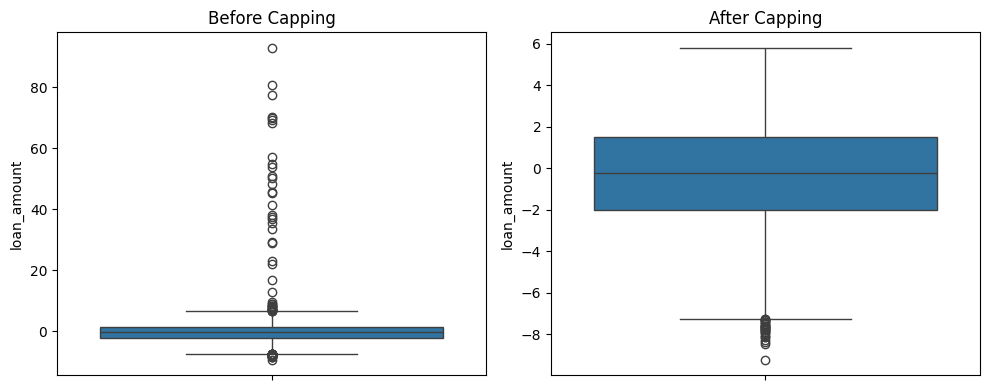

In [62]:
# Check current 99th percentile vs max, before capping
print("99th percentile:", df_fe['loan_amount'].quantile(0.99))
print("Max before capping:", df_fe['loan_amount'].max())

# Cap at the 99th percentile
cap_value = df_fe['loan_amount'].quantile(0.99)
df_fe['loan_amount'] = df_fe['loan_amount'].clip(upper=cap_value)

print("Max after capping:", df_fe['loan_amount'].max())

# Visual confirmation
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['loan_amount'], ax=axes[0])
axes[0].set_title("Before Capping")
sns.boxplot(y=df_fe['loan_amount'], ax=axes[1])
axes[1].set_title("After Capping")
plt.tight_layout()
plt.show()

In [63]:
df_fe = pd.get_dummies(df_fe, columns=['employment_type'], drop_first=True)

print(df_fe.shape)
print(df_fe.columns.tolist())
df_fe.head()


(10000, 21)
['credit_score', 'loan_amount', 'loan_term_months', 'age', 'employment_years', 'num_credit_lines', 'num_late_payments', 'savings_balance', 'num_dependents', 'monthly_expenses', 'existing_loans', 'mortgage_balance', 'annual_spend', 'num_bank_accounts', 'avg_transaction_value', 'num_inquiries_6mo', 'investment_balance', 'risk_category', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed']


,credit_score,loan_amount,loan_term_months,age,employment_years,num_credit_lines,num_late_payments,savings_balance,num_dependents,monthly_expenses,...,mortgage_balance,annual_spend,num_bank_accounts,avg_transaction_value,num_inquiries_6mo,investment_balance,risk_category,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,638.0,-6.339496,0.350506,24,-2.133639,0.048107,0.883843,-0.736041,0.280664,-0.544184,...,0.485348,0.792439,-0.824339,2.646163,-2.566462,-0.085419,High_Risk,True,False,False
1,572.0,0.732662,-1.014284,22,1.594057,-2.531008,1.615773,-4.658861,0.608795,0.729690,...,-0.559708,-0.842674,-0.370175,-1.195547,0.250621,-2.516402,Low_Risk,True,False,False
2,504.0,-0.516390,-3.494384,23,0.692334,0.530660,0.593272,-0.429524,1.963192,0.665294,...,-1.920335,-0.911276,-2.303786,3.814886,-2.071418,-0.619695,Low_Risk,True,False,False
3,468.0,-1.099379,2.117065,23,-1.849336,-0.641152,2.013695,0.955201,-4.337374,-0.547351,...,-0.231922,-0.087163,1.668250,-2.377077,-0.536020,-1.021003,Low_Risk,True,False,False
4,460.0,4.736155,-1.545213,25,0.335158,-1.009353,2.940792,-1.953473,1.292819,-0.848349,...,-0.446521,0.182940,-2.299213,1.067097,1.069284,0.446097,Low_Risk,True,False,False


In [64]:
risk_order = {'Low_Risk': 0, 'Medium_Risk': 1, 'High_Risk': 2}
df_fe['risk_category'] = df_fe['risk_category'].map(risk_order)

print(df_fe['risk_category'].value_counts().sort_index())

risk_category
0    4953
1    2995
2    2052
Name: count, dtype: int64


In [65]:
from sklearn.model_selection import train_test_split

X = df_fe.drop(columns='risk_category')
y = df_fe['risk_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Train shape: (8000, 20)
Test shape: (2000, 20)

Train class distribution:
risk_category
0    0.49525
1    0.29950
2    0.20525
Name: proportion, dtype: float64

Test class distribution:
risk_category
0    0.4955
1    0.2995
2    0.2050
Name: proportion, dtype: float64


In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sanity check: train mean should be ~0, std ~1; test will be CLOSE but not exact (expected!)
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).describe().loc[['mean', 'std']])

      credit_score   loan_amount  loan_term_months           age  \
mean -8.353318e-16 -1.421085e-17      1.687539e-17 -1.341149e-16   
std   1.000063e+00  1.000063e+00      1.000063e+00  1.000063e+00   

      employment_years  num_credit_lines  num_late_payments  savings_balance  \
mean     -4.263256e-17      2.664535e-18       3.330669e-17     1.776357e-17   
std       1.000063e+00      1.000063e+00       1.000063e+00     1.000063e+00   

      num_dependents  monthly_expenses  existing_loans  mortgage_balance  \
mean    6.217249e-18      1.154632e-17   -7.993606e-18     -3.552714e-18   
std     1.000063e+00      1.000063e+00    1.000063e+00      1.000063e+00   

      annual_spend  num_bank_accounts  avg_transaction_value  \
mean  2.131628e-17       3.996803e-17           7.105427e-18   
std   1.000063e+00       1.000063e+00           1.000063e+00   

      num_inquiries_6mo  investment_balance  employment_type_Salaried  \
mean      -6.661338e-18       -5.329071e-18              6.

In [67]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

svm_baseline = SVC(kernel='rbf', random_state=42)
svm_baseline.fit(X_train_scaled, y_train)

y_pred = svm_baseline.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low_Risk', 'Medium_Risk', 'High_Risk']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.894

Classification Report:
              precision    recall  f1-score   support

    Low_Risk       0.89      0.94      0.91       991
 Medium_Risk       0.89      0.88      0.89       599
   High_Risk       0.90      0.80      0.85       410

    accuracy                           0.89      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.89      0.89      0.89      2000

Confusion Matrix:
[[929  43  19]
 [ 52 530  17]
 [ 59  22 329]]


In [68]:
from sklearn.svm import SVC

kernels = ['linear', 'rbf', 'poly']
results = {}

for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[k] = acc
    print(f"Kernel: {k:8s} | Accuracy: {acc:.4f}")

Kernel: linear   | Accuracy: 0.7385
Kernel: rbf      | Accuracy: 0.8940
Kernel: poly     | Accuracy: 0.8465


In [69]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
}

svm_tuned = SVC(kernel='rbf', class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    svm_tuned, param_grid,
    scoring='f1_macro',   # macro F1, not accuracy — treats all 3 classes equally
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV macro F1:", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'C': 1, 'gamma': 0.1}
Best CV macro F1: 0.8887874791773223


In [70]:
best_svm = grid_search.best_estimator_

y_pred_tuned = best_svm.predict(X_test_scaled)

print("=== TUNED MODEL (class_weight='balanced', C=1, gamma=0.1) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Low_Risk', 'Medium_Risk', 'High_Risk']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))


=== TUNED MODEL (class_weight='balanced', C=1, gamma=0.1) ===
Accuracy: 0.9025

Classification Report:
              precision    recall  f1-score   support

    Low_Risk       0.92      0.92      0.92       991
 Medium_Risk       0.88      0.91      0.90       599
   High_Risk       0.89      0.85      0.87       410

    accuracy                           0.90      2000
   macro avg       0.90      0.89      0.89      2000
weighted avg       0.90      0.90      0.90      2000

Confusion Matrix:
[[910  52  29]
 [ 35 548  16]
 [ 41  22 347]]


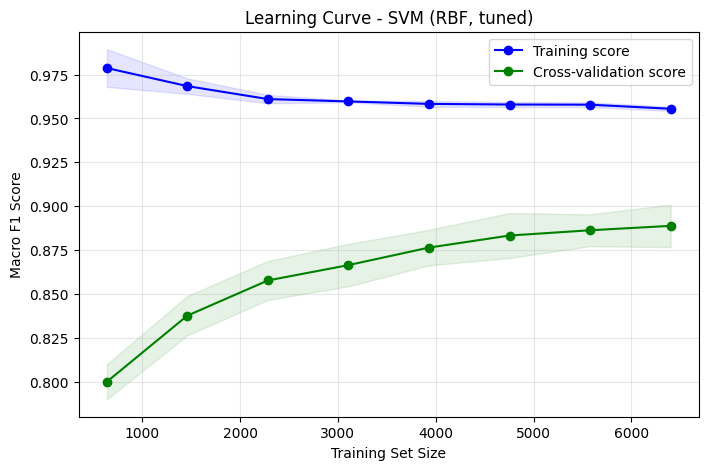

Final train sizes: [ 640 1462 2285 3108 3931 4754 5577 6400]
Final training score: 0.9555396494207091
Final validation score: 0.8887874791773223
Gap (train - val): 0.06675217024338687


In [71]:
from sklearn.model_selection import learning_curve
import numpy as np

best_params = grid_search.best_params_

svm_final = SVC(kernel='rbf', class_weight='balanced', 
                 C=best_params['C'], gamma=best_params['gamma'], 
                 random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    svm_final, X_train_scaled, y_train,
    cv=5, scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1, random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')

plt.plot(train_sizes, val_mean, 'o-', color='green', label='Cross-validation score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='green')

plt.xlabel('Training Set Size')
plt.ylabel('Macro F1 Score')
plt.title('Learning Curve - SVM (RBF, tuned)')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

print("Final train sizes:", train_sizes)
print("Final training score:", train_mean[-1])
print("Final validation score:", val_mean[-1])
print("Gap (train - val):", train_mean[-1] - val_mean[-1])